# GOAL
## We'll investigate questions such as:
### At what times is taxi demand highest?
### How does demand change throughout the week?
### Are there monthly or seasonal patterns?
### Which pickup and drop-off locations are most popular?
### How does trip duration vary by time of day?
### What is the relationship between distance, fare, and trip duration?
### Are there unusual trips or suspicious transactions?
### How does passenger behaviour vary between weekdays and weekends?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_parquet(
    "../data/raw/yellow_tripdata_2026-01.parquet"
)

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [5]:
df.tail()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3724884,2,2026-01-31 23:26:00,2026-01-31 23:39:16,NaN,1.62,NaN,NaN,237,161,0,17.09,0.0,0.5,0.0,0.0,1.0,21.84,NaN,NaN,0.75
3724885,2,2026-01-31 23:33:53,2026-01-31 23:34:07,NaN,0.00,NaN,NaN,42,42,0,23.19,0.0,0.5,0.0,0.0,1.0,24.69,NaN,NaN,0.00
3724886,2,2026-01-31 23:40:23,2026-01-31 23:56:10,NaN,6.84,NaN,NaN,137,69,0,29.21,0.0,0.5,0.0,0.0,1.0,33.96,NaN,NaN,0.75
3724887,2,2026-01-31 23:10:21,2026-01-31 23:20:00,NaN,1.53,NaN,NaN,137,162,0,19.19,0.0,0.5,0.0,0.0,1.0,23.94,NaN,NaN,0.75
3724888,2,2026-01-31 23:43:12,2026-01-31 23:57:45,NaN,1.04,NaN,NaN,148,148,0,16.49,0.0,0.5,0.0,0.0,1.0,21.24,NaN,NaN,0.75


In [6]:
df.shape

(3724889, 20)

In [7]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3724889 entries, 0 to 3724888
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     str           
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64   

In [9]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

In [10]:
df.memory_usage(deep=True).sum() / (1024 ** 2)

np.float64(528.4538297653198)

In [11]:
df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

In [12]:
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

passenger_count          29.210481
congestion_surcharge     29.210481
store_and_fwd_flag       29.210481
RatecodeID               29.210481
Airport_fee              29.210481
tpep_dropoff_datetime     0.000000
VendorID                  0.000000
tpep_pickup_datetime      0.000000
DOLocationID              0.000000
payment_type              0.000000
trip_distance             0.000000
PULocationID              0.000000
extra                     0.000000
fare_amount               0.000000
mta_tax                   0.000000
tip_amount                0.000000
improvement_surcharge     0.000000
tolls_amount              0.000000
total_amount              0.000000
cbd_congestion_fee        0.000000
dtype: float64

In [13]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
count,3.724889e+06,3724889,3724889,2.636831e+06,3.724889e+06,2.636831e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,3.724889e+06,2.636831e+06,2.636831e+06,3.724889e+06
mean,1.873598e+00,2026-01-17 01:44:52.106518,2026-01-17 02:02:03.696138,1.256271e+00,6.455647e+00,5.218853e+00,1.614372e+02,1.609936e+02,8.465637e-01,2.080425e+01,1.023055e+00,4.833766e-01,2.608142e+00,4.983751e-01,9.479130e-01,2.917853e+01,2.154870e+00,1.482938e-01,5.196437e-01
min,1.000000e+00,2025-12-31 23:57:29,2025-12-31 23:57:32,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.555200e+03,-7.500000e+00,-5.000000e-01,-8.888000e+01,-9.450000e+01,-1.000000e+00,-2.560200e+03,-2.500000e+00,-1.750000e+00,-7.500000e-01
25%,2.000000e+00,2026-01-09 17:51:59,2026-01-09 18:08:47,1.000000e+00,1.000000e+00,1.000000e+00,1.140000e+02,1.070000e+02,0.000000e+00,1.000000e+01,0.000000e+00,5.000000e-01,0.000000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2.500000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,2026-01-16 21:20:56,2026-01-16 21:36:14,1.000000e+00,1.810000e+00,1.000000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.560000e+01,0.000000e+00,5.000000e-01,2.000000e+00,0.000000e+00,1.000000e+00,2.305000e+01,2.500000e+00,0.000000e+00,7.500000e-01
75%,2.000000e+00,2026-01-24 07:25:11,2026-01-24 07:40:22,1.000000e+00,3.730000e+00,1.000000e+00,2.330000e+02,2.340000e+02,1.000000e+00,2.610000e+01,2.500000e+00,5.000000e-01,3.710000e+00,0.000000e+00,1.000000e+00,3.383000e+01,2.500000e+00,0.000000e+00,7.500000e-01
max,7.000000e+00,2026-02-01 00:45:01,2026-02-01 23:35:31,9.000000e+00,2.690975e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,2.555200e+03,1.746000e+01,4.750000e+00,7.660000e+02,1.222200e+02,1.000000e+00,2.560200e+03,2.500000e+00,2.675000e+01,7.500000e-01
std,7.014583e-01,NaN,NaN,6.702431e-01,6.488855e+02,1.965370e+01,6.706657e+01,7.103604e+01,7.120493e-01,1.892701e+01,1.707322e+00,1.145558e-01,3.917405e+00,2.131731e+00,2.654859e-01,2.258553e+01,9.423645e-01,5.336714e-01,3.568099e-01


In [14]:
print("Mean:", df["trip_distance"].mean())
print("Median:", df["trip_distance"].median())
print("Minimum:", df["trip_distance"].min())
print("Maximum:", df["trip_distance"].max())

Mean: 6.455646860886324
Median: 1.81
Minimum: 0.0
Maximum: 269097.48


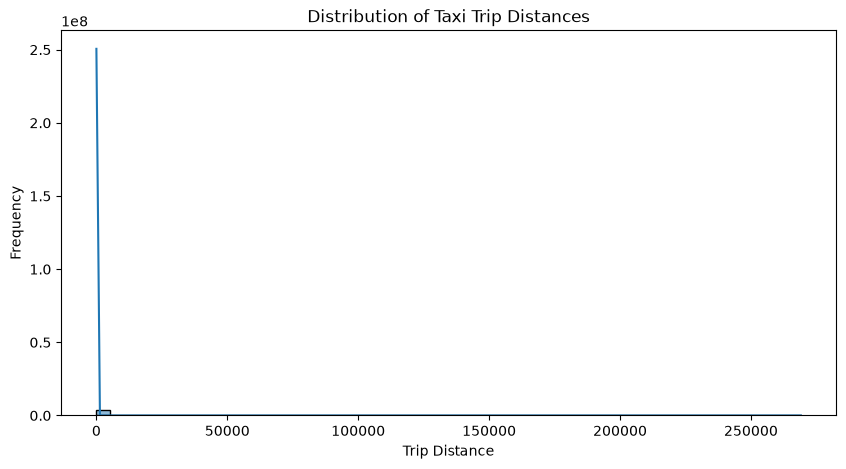

In [15]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["trip_distance"],
    bins=50,
    kde=True
)

plt.title("Distribution of Taxi Trip Distances")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")

plt.show()

In [16]:
df["passenger_count"].value_counts(
    dropna=False
).sort_index()

passenger_count
0.0      14787
1.0    2150994
2.0     334370
3.0      72864
4.0      49738
5.0       9184
6.0       4887
7.0          2
8.0          4
9.0          1
NaN    1088058
Name: count, dtype: int64

In [17]:
extreme_trips = df.nlargest(
    10,
    "trip_distance"
)

extreme_trips[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "total_amount",
    "PULocationID",
    "DOLocationID",
    "passenger_count"
]]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount,PULocationID,DOLocationID,passenger_count
3524923,2026-01-28 01:08:00,2026-01-28 01:16:00,269097.48,12.19,16.94,79,144,NaN
3632367,2026-01-30 13:00:00,2026-01-30 13:38:00,237567.19,72.99,81.95,42,130,NaN
3285750,2026-01-21 16:31:00,2026-01-21 16:40:00,236216.69,13.58,21.33,234,107,NaN
3131676,2026-01-17 10:40:00,2026-01-17 10:57:00,236183.06,22.75,34.96,137,82,NaN
2704619,2026-01-02 21:31:00,2026-01-02 21:55:00,221544.91,31.21,39.55,249,41,NaN
2688274,2026-01-02 07:07:00,2026-01-02 07:18:00,221436.73,27.61,32.36,231,161,NaN
3131406,2026-01-17 10:39:00,2026-01-17 10:56:00,196490.48,33.59,38.34,13,162,NaN
3571687,2026-01-29 07:51:00,2026-01-29 08:26:00,192081.68,60.20,64.95,33,246,NaN
2820951,2026-01-07 17:51:00,2026-01-07 17:56:00,184908.33,12.18,16.93,164,186,NaN
3499856,2026-01-27 14:46:00,2026-01-27 16:10:00,183363.75,71.01,75.76,230,74,NaN


In [18]:
df["trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["trip_duration_minutes"].describe()

count    3.724889e+06
mean     1.719316e+01
std      2.517802e+01
min     -1.170000e+01
25%      8.066667e+00
50%      1.336667e+01
75%      2.120000e+01
max      7.507900e+03
Name: trip_duration_minutes, dtype: float64

In [19]:
print(
    "Negative durations:",
    (df["trip_duration_minutes"] < 0).sum()
)

print(
    "Zero durations:",
    (df["trip_duration_minutes"] == 0).sum()
)

Negative durations: 1
Zero durations: 45069


In [20]:
df["trip_distance"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

0.500     1.81
0.750     3.73
0.900     8.56
0.950    12.45
0.990    19.54
0.999    29.79
Name: trip_distance, dtype: float64

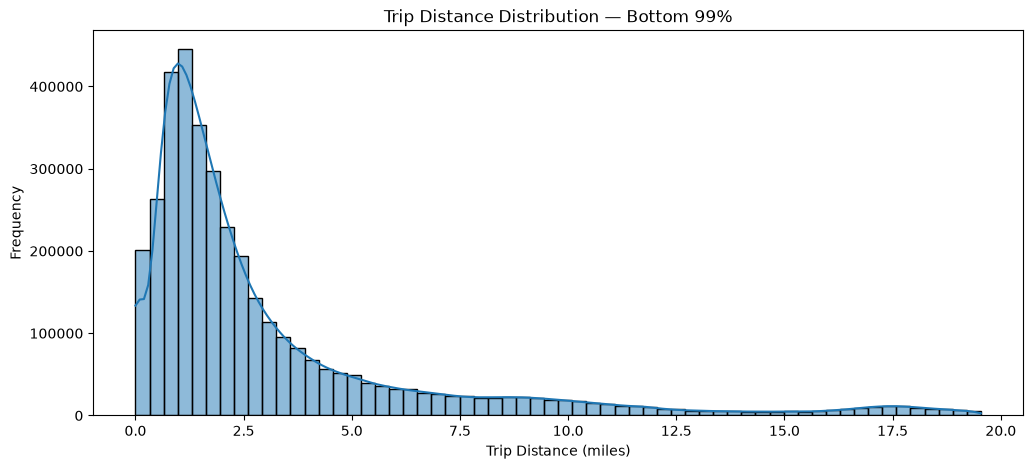

In [21]:
distance_99 = df["trip_distance"].quantile(0.99)

plt.figure(figsize=(12, 5))

sns.histplot(
    data=df[df["trip_distance"] <= distance_99],
    x="trip_distance",
    bins=60,
    kde=True
)

plt.title("Trip Distance Distribution — Bottom 99%")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")

plt.show()

In [22]:
passenger_distribution = (
    df["passenger_count"]
    .value_counts(normalize=True, dropna=False)
    .sort_index() * 100
)

passenger_distribution

passenger_count
0.0     0.396978
1.0    57.746526
2.0     8.976643
3.0     1.956139
4.0     1.335288
5.0     0.246558
6.0     0.131199
7.0     0.000054
8.0     0.000107
9.0     0.000027
NaN    29.210481
Name: proportion, dtype: float64

In [23]:
extreme_trips = df.nlargest(
    10,
    "trip_distance"
).copy()

extreme_trips["speed_mph"] = (
    extreme_trips["trip_distance"] /
    (extreme_trips["trip_duration_minutes"] / 60)
)

extreme_trips[[
    "trip_distance",
    "trip_duration_minutes",
    "speed_mph",
    "fare_amount",
    "total_amount",
    "PULocationID",
    "DOLocationID"
]]

,trip_distance,trip_duration_minutes,speed_mph,fare_amount,total_amount,PULocationID,DOLocationID
3524923,269097.48,8.0,2.018231e+06,12.19,16.94,79,144
3632367,237567.19,38.0,3.751061e+05,72.99,81.95,42,130
3285750,236216.69,9.0,1.574778e+06,13.58,21.33,234,107
3131676,236183.06,17.0,8.335873e+05,22.75,34.96,137,82
2704619,221544.91,24.0,5.538623e+05,31.21,39.55,249,41
2688274,221436.73,11.0,1.207837e+06,27.61,32.36,231,161
3131406,196490.48,17.0,6.934958e+05,33.59,38.34,13,162
3571687,192081.68,35.0,3.292829e+05,60.20,64.95,33,246
2820951,184908.33,5.0,2.218900e+06,12.18,16.93,164,186
3499856,183363.75,84.0,1.309741e+05,71.01,75.76,230,74


In [24]:
print(df["trip_distance"].max())

print(
    df.loc[
        df["trip_distance"].idxmax(),
        [
            "tpep_pickup_datetime",
            "tpep_dropoff_datetime",
            "trip_distance",
            "fare_amount",
            "total_amount",
            "PULocationID",
            "DOLocationID"
        ]
    ]
)

269097.48
tpep_pickup_datetime     2026-01-28 01:08:00
tpep_dropoff_datetime    2026-01-28 01:16:00
trip_distance                      269097.48
fare_amount                            12.19
total_amount                           16.94
PULocationID                              79
DOLocationID                             144
Name: 3524923, dtype: object


In [25]:
df[df["trip_duration_minutes"] < 0][[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount"
]]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount
1465434,2026-01-17 19:30:00,2026-01-17 19:18:18,-11.7,16.5,66.5


In [26]:
longest_trips = df.nlargest(
    10,
    "trip_duration_minutes"
)

longest_trips[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_duration_minutes",
    "trip_distance",
    "fare_amount",
    "total_amount"
]]

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes,trip_distance,fare_amount,total_amount
1560244,2026-01-19 00:35:57,2026-01-24 05:43:51,7507.900000,0.00,70.0,71.50
572461,2026-01-08 12:06:24,2026-01-12 15:20:38,5954.233333,0.00,3.7,5.20
710966,2026-01-09 20:41:45,2026-01-13 12:55:05,5293.333333,2.90,15.6,20.60
2027357,2026-01-23 22:38:23,2026-01-27 12:32:58,5154.583333,4.86,67.4,71.65
100303,2026-01-02 14:11:42,2026-01-05 20:44:12,4712.500000,0.00,25.5,26.00
1740426,2026-01-21 09:04:19,2026-01-24 08:50:35,4306.266667,21.73,82.8,86.05
469655,2026-01-07 10:56:28,2026-01-10 01:26:30,3750.033333,0.00,40.5,41.00
2127024,2026-01-25 00:43:10,2026-01-27 11:28:52,3525.700000,48.65,-2555.2,-2560.20
2127025,2026-01-25 00:43:10,2026-01-27 11:28:52,3525.700000,48.65,2555.2,2560.20
2050814,2026-01-24 09:28:41,2026-01-26 11:51:47,3023.100000,2.10,10.0,13.25


In [27]:
print("Earliest pickup:")
print(df["tpep_pickup_datetime"].min())

print("Latest pickup:")
print(df["tpep_pickup_datetime"].max())

print("Earliest drop-off:")
print(df["tpep_dropoff_datetime"].min())

print("Latest drop-off:")
print(df["tpep_dropoff_datetime"].max())

Earliest pickup:
2025-12-31 23:57:29
Latest pickup:
2026-02-01 00:45:01
Earliest drop-off:
2025-12-31 23:57:32
Latest drop-off:
2026-02-01 23:35:31


In [28]:
df["tpep_pickup_datetime"].dt.to_period("M").value_counts()

tpep_pickup_datetime
2026-01    3724882
2025-12          6
2026-02          1
Freq: M, Name: count, dtype: int64

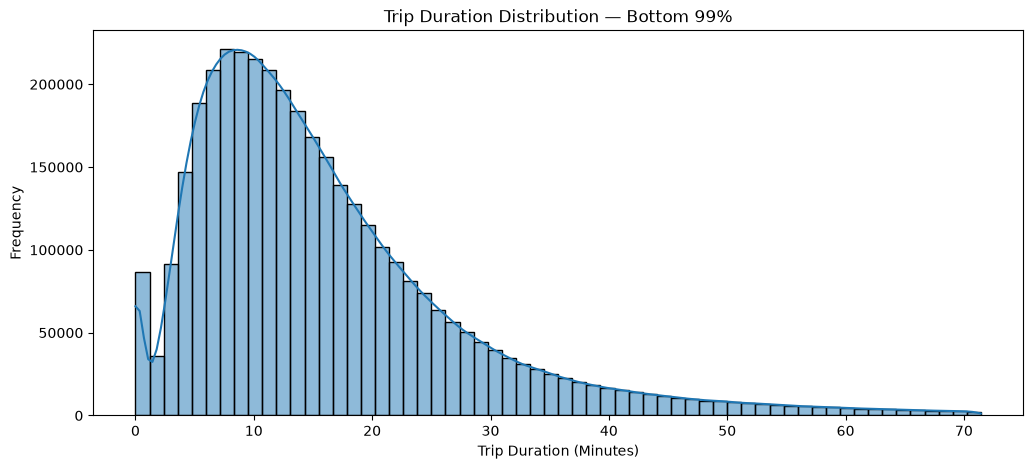

In [29]:
duration_99 = df["trip_duration_minutes"].quantile(0.99)

plt.figure(figsize=(12, 5))

sns.histplot(
    df.loc[
        df["trip_duration_minutes"].between(0, duration_99),
        "trip_duration_minutes"
    ],
    bins=60,
    kde=True
)

plt.title("Trip Duration Distribution — Bottom 99%")
plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Frequency")

plt.show()

# Preliminary EDA Findings — Taxi Trip Dataset

## Dataset characteristics
- Observations: 3,724,889
- Columns: 20
- Mean trip distance: 6.46 miles
- Median trip distance: 1.81 miles
- Mean trip duration: 17.19 minutes
- Median trip duration: 13.37 minutes

## Data-quality observations
- Approximately 29% passenger counts missing.
- 1,478 records with zero passengers.
- 45,069 zero-duration trips.
- One negative-duration trip.
- Maximum trip duration: approximately 52 days.
- Extremely large trip-distance values.

## Preliminary interpretations
1. Trip distance appears strongly right-skewed.
2. Extreme observations may influence the mean.
3. Passenger-count missingness requires investigation.
4. Timestamp inconsistencies require validation.
5. Dataset date coverage must be verified.

## Cleaning decisions
No observations removed. All anomalies retained pending investigation.

In [30]:

percentile_99 = df['trip_distance'].quantile(0.99)
print(f"The 99th percentile of trip distance is: {percentile_99}")


The 99th percentile of trip distance is: 19.54


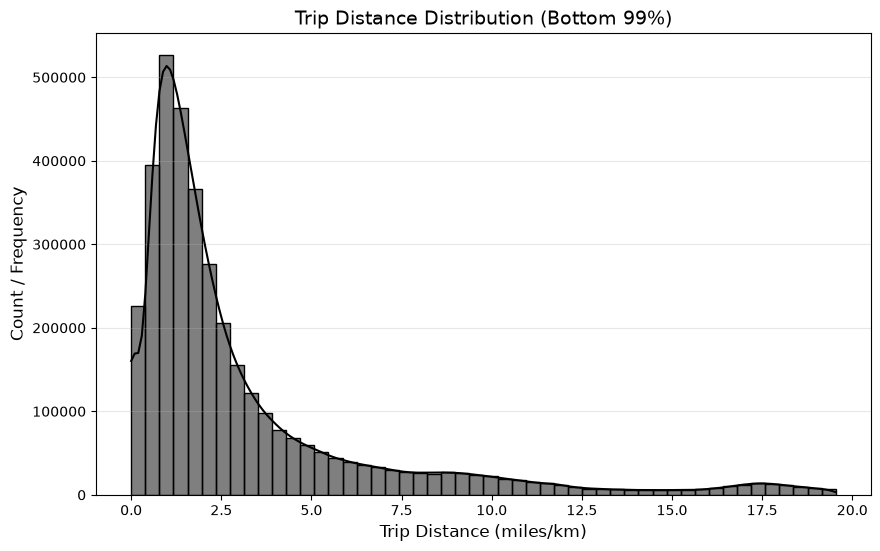

In [32]:
bottom_99_df = df[df['trip_distance'] <= percentile_99]

# 4. Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(data=bottom_99_df, x='trip_distance', kde=True, bins=50, color='black')

# 5. Customize the chart labels
plt.title('Trip Distance Distribution (Bottom 99%)', fontsize=14)
plt.xlabel('Trip Distance (miles/km)', fontsize=12)
plt.ylabel('Count / Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.show()

In [33]:
missing_percentage = df['passenger_count'].isnull().mean() * 100

print(f"Missing percentage: {missing_percentage}%")

Missing percentage: 29.21048117138524%


In [35]:
longest_trips = df.nlargest(10, 'trip_distance')

# 3. Calculate the average speed for each of these 10 trips (Speed = Distance / Time)
longest_trips["duration_hours"] = (
    longest_trips["tpep_dropoff_datetime"] -
    longest_trips["tpep_pickup_datetime"]
).dt.total_seconds() / 3600
longest_trips['speed_mph'] = longest_trips['trip_distance'] / longest_trips['duration_hours']

# 4. Calculate the overall mean speed of these 10 trips
average_speed = longest_trips['speed_mph'].mean()

print(f"The average speed of the 10 longest trips is: {average_speed:.2f} mph")

The average speed of the 10 longest trips is: 993605.41 mph


In [36]:
# First, ensure the column is converted to datetime type
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])

# Print start and end dates
print("Start Date:", df["tpep_pickup_datetime"].min())
print("End Date:  ", df["tpep_pickup_datetime"].max())

Start Date: 2025-12-31 23:57:29
End Date:   2026-02-01 00:45:01


# Systematic Data Quality Assessment

## Audit 1 — Completeness (Missing Values)

In [4]:
missing_audit = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percentage": df.isnull().mean() * 100,
    "available_count": df.notnull().sum(),
    "data_type": df.dtypes.astype(str)
})

missing_audit = missing_audit.sort_values(
    by="missing_percentage",
    ascending=False
)

missing_audit

,missing_count,missing_percentage,available_count,data_type
passenger_count,1088058,29.210481,2636831,float64
congestion_surcharge,1088058,29.210481,2636831,float64
store_and_fwd_flag,1088058,29.210481,2636831,str
RatecodeID,1088058,29.210481,2636831,float64
Airport_fee,1088058,29.210481,2636831,float64
tpep_dropoff_datetime,0,0.000000,3724889,datetime64[us]
VendorID,0,0.000000,3724889,int32
tpep_pickup_datetime,0,0.000000,3724889,datetime64[us]
DOLocationID,0,0.000000,3724889,int32
payment_type,0,0.000000,3724889,int64


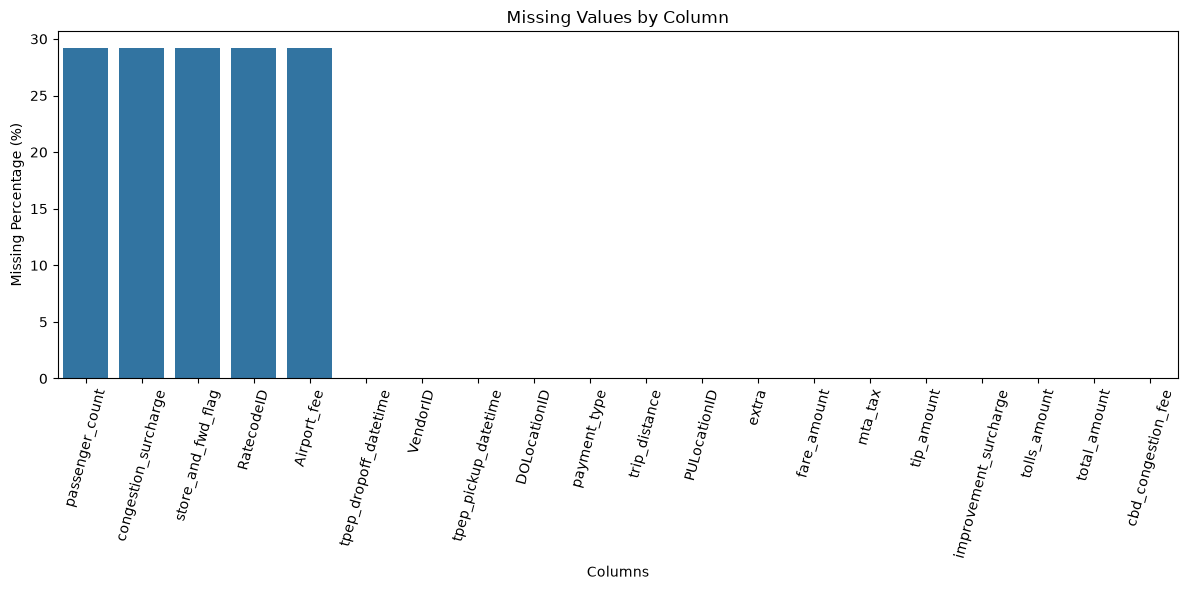

In [5]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=missing_audit.index,
    y=missing_audit["missing_percentage"]
)

plt.xticks(rotation=75)
plt.title("Missing Values by Column")
plt.ylabel("Missing Percentage (%)")
plt.xlabel("Columns")

plt.tight_layout()
plt.show()

In [6]:
missing_pattern = (
    df.isnull()
    .groupby([
        df["passenger_count"].isnull(),
        df["RatecodeID"].isnull()
    ])
    .size()
)

missing_pattern

passenger_count  RatecodeID
False            False         2636831
True             True          1088058
dtype: int64

## Audit 2 — Uniqueness (Duplicate Records)

In [7]:
duplicate_count = df.duplicated().sum()

print("Exact duplicate records:", duplicate_count)

print(
    "Duplicate percentage:",
    df.duplicated().mean() * 100
)

Exact duplicate records: 0
Duplicate percentage: 0.0


In [8]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee


In [9]:
candidate_duplicates = df.duplicated(
    subset=[
        "tpep_pickup_datetime",
        "tpep_dropoff_datetime",
        "PULocationID",
        "DOLocationID",
        "trip_distance",
        "fare_amount"
    ],
    keep=False
)

print("Candidate duplicate records:", candidate_duplicates.sum())

Candidate duplicate records: 1078


## Audit 3 — Validity (Business Rule Validation)

In [10]:
numeric_checks = {
    "negative_trip_distance": (
        df["trip_distance"] < 0
    ).sum(),

    "zero_trip_distance": (
        df["trip_distance"] == 0
    ).sum(),

    "negative_fare": (
        df["fare_amount"] < 0
    ).sum(),

    "zero_fare": (
        df["fare_amount"] == 0
    ).sum(),

    "negative_total_amount": (
        df["total_amount"] < 0
    ).sum(),

    "negative_passenger_count": (
        df["passenger_count"] < 0
    ).sum()
}

pd.Series(numeric_checks, name="record_count")

negative_trip_distance           0
zero_trip_distance          125738
negative_fare                39463
zero_fare                     2082
negative_total_amount        39984
negative_passenger_count         0
Name: record_count, dtype: int64

In [11]:
categorical_columns = [
    "store_and_fwd_flag",
    "payment_type",
    "RatecodeID"
]

for col in categorical_columns:

    print(f"\nColumn: {col}")

    print(
        df[col].value_counts(dropna=False)
    )


Column: store_and_fwd_flag
store_and_fwd_flag
N      2634494
NaN    1088058
Y         2337
Name: count, dtype: int64

Column: payment_type
payment_type
1    2249747
0    1088058
2     314043
4      56400
3      16641
Name: count, dtype: int64

Column: RatecodeID
RatecodeID
1.0     2390495
NaN     1088058
99.0     110864
2.0       83592
5.0       32030
3.0       11541
4.0        8304
6.0           5
Name: count, dtype: int64


## Audit 4 — Temporal Integrity

In [14]:
df["audit_trip_duration_minutes"] = (
    df["tpep_dropoff_datetime"] -
    df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

df["audit_trip_duration_minutes"]

0           5.550000
1           5.716667
2           8.883333
3          42.800000
4          13.500000
             ...    
3724884    13.266667
3724885     0.233333
3724886    15.783333
3724887     9.650000
3724888    14.550000
Name: audit_trip_duration_minutes, Length: 3724889, dtype: float64

In [15]:
temporal_checks = {
    "negative_duration": (
        df["audit_trip_duration_minutes"] < 0
    ).sum(),

    "zero_duration": (
        df["audit_trip_duration_minutes"] == 0
    ).sum(),

    "duration_over_24_hours": (
        df["audit_trip_duration_minutes"] > 1440
    ).sum(),

    "missing_pickup_datetime": (
        df["tpep_pickup_datetime"].isnull()
    ).sum(),

    "missing_dropoff_datetime": (
        df["tpep_dropoff_datetime"].isnull()
    ).sum()
}

pd.Series(temporal_checks, name="record_count")

negative_duration               1
zero_duration               45069
duration_over_24_hours         35
missing_pickup_datetime         0
missing_dropoff_datetime        0
Name: record_count, dtype: int64

In [16]:
negative_duration_records = df[
    df["audit_trip_duration_minutes"] < 0
]

negative_duration_records[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "audit_trip_duration_minutes",
    "trip_distance",
    "fare_amount"
]]

,tpep_pickup_datetime,tpep_dropoff_datetime,audit_trip_duration_minutes,trip_distance,fare_amount
1465434,2026-01-17 19:30:00,2026-01-17 19:18:18,-11.7,16.5,66.5


In [17]:
zero_duration_records = df[
    df["audit_trip_duration_minutes"] == 0
]

zero_duration_records[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "fare_amount",
    "total_amount"
]].head(10)

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,fare_amount,total_amount
16,2026-01-01 00:45:15,2026-01-01 00:45:15,1.54,28.9,41.58
126,2026-01-01 00:46:05,2026-01-01 00:46:05,1.79,18.4,24.15
251,2026-01-01 00:22:40,2026-01-01 00:22:40,1.24,8.6,16.32
252,2026-01-01 00:36:04,2026-01-01 00:36:04,2.00,11.4,17.15
253,2026-01-01 00:51:23,2026-01-01 00:51:23,0.83,6.5,12.25
287,2026-01-01 00:48:27,2026-01-01 00:48:27,3.83,27.5,39.90
382,2026-01-01 00:45:00,2026-01-01 00:45:00,5.38,27.5,32.50
405,2026-01-01 00:51:33,2026-01-01 00:51:33,1.22,10.0,18.90
511,2026-01-01 00:40:03,2026-01-01 00:40:03,1.69,19.8,30.66
527,2026-01-01 00:36:07,2026-01-01 00:36:07,1.13,7.9,16.38


## Audit 5 — Consistency (Relationships Between Columns)

In [18]:
df["audit_speed_mph"] = (
    df["trip_distance"] /
    (df["audit_trip_duration_minutes"] / 60)
)

In [19]:
valid_duration = (
    df["audit_trip_duration_minutes"] > 0
)

df["audit_speed_mph"] = np.nan

df.loc[valid_duration, "audit_speed_mph"] = (
    df.loc[valid_duration, "trip_distance"] /
    (
        df.loc[valid_duration, "audit_trip_duration_minutes"] / 60
    )
)

In [20]:
df["audit_speed_mph"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
)

count    3.679819e+06
mean     2.426281e+01
std      3.357625e+03
min      0.000000e+00
50%      9.253099e+00
75%      1.294274e+01
90%      1.952086e+01
95%      2.497297e+01
99%      3.522666e+01
99.9%    4.679182e+01
max      2.218900e+06
Name: audit_speed_mph, dtype: float64

In [21]:
high_speed_records = df[
    df["audit_speed_mph"] > 100
]

print(
    "Records above 100 mph:",
    len(high_speed_records)
)

Records above 100 mph: 732


In [22]:
high_speed_records[[
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "trip_distance",
    "audit_trip_duration_minutes",
    "audit_speed_mph",
    "fare_amount",
    "total_amount"
]].head(20)

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,audit_trip_duration_minutes,audit_speed_mph,fare_amount,total_amount
3951,2026-01-01 00:37:48,2026-01-01 00:38:38,20.70,0.833333,1490.400000,3.0,5.50
5325,2026-01-01 01:37:29,2026-01-01 01:37:31,0.11,0.033333,198.000000,65.0,70.60
5895,2026-01-01 01:42:55,2026-01-01 01:43:03,6.60,0.133333,2970.000000,3.0,8.00
5896,2026-01-01 01:44:00,2026-01-01 01:44:05,6.60,0.083333,4752.000000,3.0,8.00
5897,2026-01-01 01:46:29,2026-01-01 01:46:48,6.60,0.316667,1250.526316,3.0,8.00
6635,2026-01-01 01:05:55,2026-01-01 01:06:16,0.60,0.350000,102.857143,20.0,21.75
9129,2026-01-01 01:04:56,2026-01-01 01:06:23,5.40,1.450000,223.448276,3.7,9.45
11657,2026-01-01 02:48:20,2026-01-01 02:48:23,0.18,0.050000,216.000000,50.0,51.50
16839,2026-01-01 03:27:40,2026-01-01 03:27:52,0.90,0.200000,270.000000,70.0,71.50
17732,2026-01-01 04:48:16,2026-01-01 04:48:26,3.10,0.166667,1116.000000,25.0,32.10


## Audit 6 — Plausibility and Outlier Investigation

In [27]:
Q1 = df["trip_distance"].quantile(0.25)

Q3 = df["trip_distance"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:", lower_bound)
print("Upper boundary:", upper_bound)

# Step 4: Identify outliers
iqr_outliers = df[
    (df["trip_distance"] < lower_bound) |
    (df["trip_distance"] > upper_bound)
]

print("Outlier Count:", len(iqr_outliers))

print(
    "Outlier Percentage:",
    len(iqr_outliers) / len(df) * 100
)

Q1: 1.0
Q3: 3.73
IQR: 2.73
Lower boundary: -3.0949999999999998
Upper boundary: 7.824999999999999
Outlier Count: 421950
Outlier Percentage: 11.32785433337745


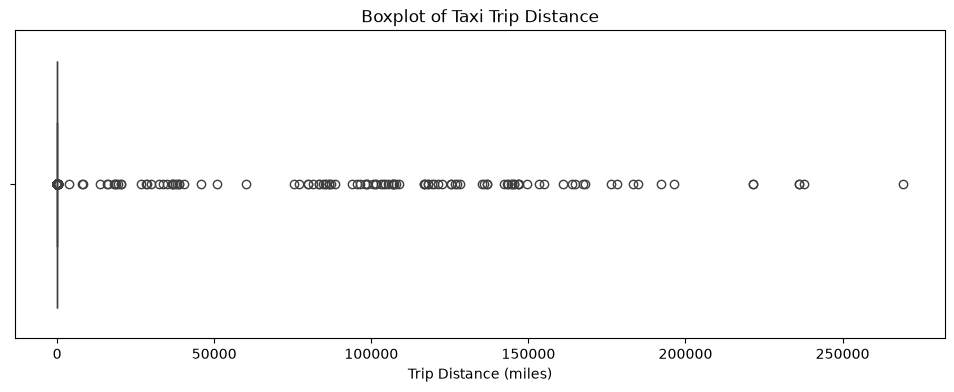

In [24]:
plt.figure(figsize=(12, 4))

sns.boxplot(
    x=df["trip_distance"]
)

plt.title("Boxplot of Taxi Trip Distance")
plt.xlabel("Trip Distance (miles)")

plt.show()

## AUDIT SUMMARY

In [28]:
quality_report = pd.DataFrame({
    "issue": [
        "Missing passenger count",
        "Missing RatecodeID",
        "Missing store_and_fwd_flag",
        "Missing congestion_surcharge",
        "Missing Airport_fee",
        "Exact duplicate records",
        "Negative trip distance",
        "Zero trip distance",
        "Negative fare",
        "Zero fare",
        "Negative total amount",
        "Zero passengers",
        "Negative trip duration",
        "Zero trip duration",
        "Duration over 24 hours",
        "Distance IQR outliers",
        "Average speed above 100 mph"
    ],

    "record_count": [
        df["passenger_count"].isnull().sum(),
        df["RatecodeID"].isnull().sum(),
        df["store_and_fwd_flag"].isnull().sum(),
        df["congestion_surcharge"].isnull().sum(),
        df["Airport_fee"].isnull().sum(),
        df.duplicated().sum(),
        (df["trip_distance"] < 0).sum(),
        (df["trip_distance"] == 0).sum(),
        (df["fare_amount"] < 0).sum(),
        (df["fare_amount"] == 0).sum(),
        (df["total_amount"] < 0).sum(),
        (df["passenger_count"] == 0).sum(),
        (df["audit_trip_duration_minutes"] < 0).sum(),
        (df["audit_trip_duration_minutes"] == 0).sum(),
        (df["audit_trip_duration_minutes"] > 1440).sum(),
        len(iqr_outliers),
        (df["audit_speed_mph"] > 100).sum()
    ]
})

quality_report["percentage"] = (
    quality_report["record_count"] /
    len(df) * 100
)

quality_report

,issue,record_count,percentage
0,Missing passenger count,1088058,29.210481
1,Missing RatecodeID,1088058,29.210481
2,Missing store_and_fwd_flag,1088058,29.210481
3,Missing congestion_surcharge,1088058,29.210481
4,Missing Airport_fee,1088058,29.210481
5,Exact duplicate records,0,0.000000
6,Negative trip distance,0,0.000000
7,Zero trip distance,125738,3.375617
8,Negative fare,39463,1.059441
9,Zero fare,2082,0.055894
